In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install bertopic

In [ ]:
import pandas as pd
import re
from urllib.parse import urlparse
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from bertopic import BERTopic
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
df = pd.read_csv("/content/drive/My Drive/Dataset.csv")
df.head()

,article_id,title,url_news,news,url_image,date,host_id,crawl_date,content_tsv_gin,content_tsv_gist
0,bb874394a0cf7f5fc2c168be91c1339e486d03c0ff3d6c...,Taylor Swift releases four 'previously unrelea...,https://www.929thebeat.com/taylor-swift-releas...,TAS Rights Management Taylor Swift is kicking ...,https://www.929thebeat.com/wp-content/uploads/...,2023-03-17 05:00:00-05:00,341,2023-03-26 13:59:42.586799,'17':157 '2010':88 '2019':118 '2023':162 'abc'...,'17':157 '2010':88 '2019':118 '2023':162 'abc'...
1,bdae8e6bc03dc16cd3e5a32db7da27cd3df64891aa7f72...,Kelly Clarkson announces 'chemistry' Las Vegas...,https://www.929thebeat.com/kelly-clarkson-anno...,Courtesy Live Nation A day after announcing th...,https://www.929thebeat.com/wp-content/uploads/...,2023-03-27 08:14:48-05:00,341,2023-03-27 13:59:02.472854,"'/kellyvegas.':199 '10':193,222,248,266 '11':2...","'/kellyvegas.':199 '10':193,222,248,266 '11':2..."
2,340e1a5826b464512449984038aa9e57dbfe53a128827a...,Jeremy Renner seen walking on specialized trea...,https://www.929thebeat.com/jeremy-renner-seen-...,Marvel Studios In an update to fans on his Ins...,https://www.929thebeat.com/wp-content/uploads/...,2023-03-27 08:03:33-05:00,341,2023-03-27 13:59:02.705067,'1':143 '2023':189 '30':148 '40':97 '52':43 'a...,'1':143 '2023':189 '30':148 '40':97 '52':43 'a...
3,a1848fc5671024492bd9b928b28c809c77a10fff0d9d88...,'John Wick: Chapter 4' tops the box office wit...,https://www.929thebeat.com/john-wick-chapter-4...,Lionsgate John Wick: Chapter 4 blew away the c...,https://www.929thebeat.com/wp-content/uploads/...,2023-03-27 05:00:00-05:00,341,2023-03-27 13:59:03.667445,'..':171 '105':157 '137.5':69 '140.8':149 '202...,'..':171 '105':157 '137.5':69 '140.8':149 '202...
4,2089e6dec89da306bacd8ab8877af5ae6500a8740ce54f...,Selena Gomez says Hailey Bieber reached out to...,https://www.929thebeat.com/selena-gomez-says-h...,Kevin Mazur/Getty Images Selena Gomez is tryin...,https://www.929thebeat.com/wp-content/uploads/...,2023-03-24 08:43:19-05:00,341,2023-03-27 13:59:07.228008,'2023':143 'abc':144 'advoc':73 'alleg':117 'a...,'2023':143 'abc':144 'advoc':73 'alleg':117 'a...


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

print("\nMissing Values (%):\n", df.isnull().mean() * 100)

print("Duplicate article_ids:", df['article_id'].duplicated().sum())
print("Duplicate titles:", df['title'].duplicated().sum())
print("Duplicate news content:", df['news'].duplicated().sum())

Dataset Shape: (94877, 10)

Data Types:
 article_id          object
title               object
url_news            object
news                object
url_image           object
date                object
host_id              int64
crawl_date          object
content_tsv_gin     object
content_tsv_gist    object
dtype: object

Missing Values (%):
 article_id          0.000000
title               0.000000
url_news            0.000000
news                0.000000
url_image           1.969919
date                0.661910
host_id             0.000000
crawl_date          0.000000
content_tsv_gin     0.000000
content_tsv_gist    0.000000
dtype: float64
Duplicate article_ids: 0
Duplicate titles: 4370
Duplicate news content: 1005


In [ ]:
df['domain'] = df['url_news'].apply(lambda x: urlparse(str(x)).netloc if pd.notnull(x) else None)

print("Unique news outlets:", df['domain'].nunique())

Unique news outlets: 158


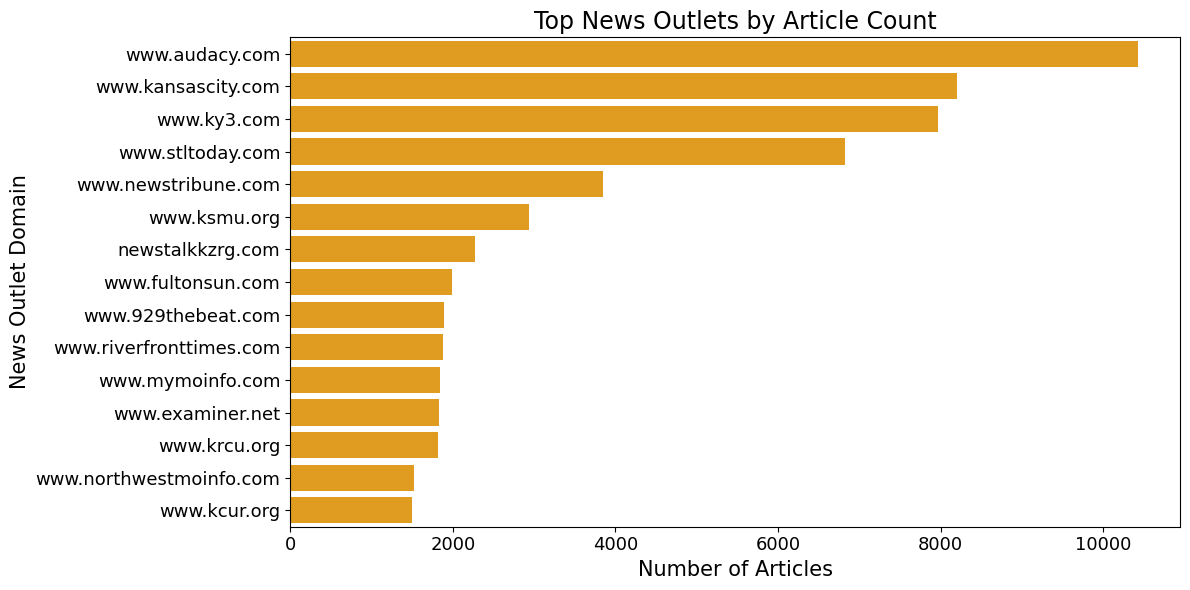

In [ ]:
top_domains = df['domain'].value_counts().head(15)

plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 13

plt.figure(figsize=(12, 6))
sns.barplot(x=top_domains.values, y=top_domains.index, color='orange')
plt.title('Top News Outlets by Article Count', size=17)
plt.xlabel('Number of Articles', size=15)
plt.ylabel('News Outlet Domain', size=15)
plt.tight_layout()
plt.show()

In [ ]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text))                  # remove HTML
    text = re.sub(r'http\S+|www.\S+', '', text)             # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)                 # remove non-alphabetic
    return text.lower()

df['cleaned_news'] = df['news'].apply(clean_text)

In [ ]:
stop_words = set(stopwords.words('english'))
df['tokens'] = df['cleaned_news'].apply(lambda x: [word for word in word_tokenize(x) if word not in stop_words])

In [ ]:
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

In [ ]:
lemmatizer = WordNetLemmatizer()
def lemmatize(tokens):
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

df['lemmatized'] = df['tokens'].apply(lemmatize)
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))

In [ ]:
df['sentiment'] = df['processed_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

df['word_count'] = df['processed_text'].apply(lambda x: len(str(x).split()))

In [ ]:
df['word_count'].describe()

,word_count
count,94877.000000
mean,277.316262
std,286.944380
min,1.000000
25%,83.000000
50%,205.000000
75%,398.000000
max,9724.000000


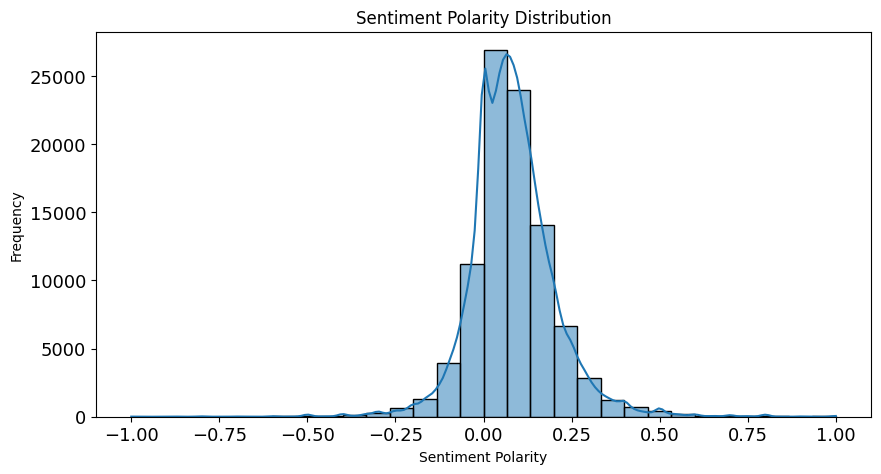

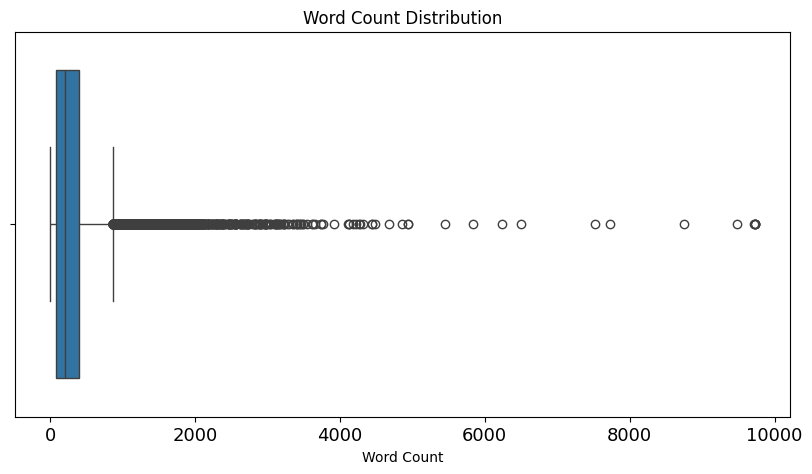

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['word_count'])
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(df['processed_text'])

In [ ]:
from umap import UMAP

umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)

topic_model = BERTopic(
    umap_model=umap_model,
    vectorizer_model=TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2, ngram_range=(1, 2)),
    nr_topics=20,
    min_topic_size=30,
    verbose=True
)

In [ ]:
topics, probs = topic_model.fit_transform(df['processed_text'].tolist())

2025-04-21 03:54:29,938 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2965 [00:00<?, ?it/s]

2025-04-21 03:55:55,709 - BERTopic - Embedding - Completed ✓
2025-04-21 03:55:55,710 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-21 03:57:56,850 - BERTopic - Dimensionality - Completed ✓
2025-04-21 03:57:56,852 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-21 03:58:01,799 - BERTopic - Cluster - Completed ✓
2025-04-21 03:58:01,801 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-04-21 03:59:03,190 - BERTopic - Representation - Completed ✓
2025-04-21 03:59:03,283 - BERTopic - Topic reduction - Reducing number of topics
2025-04-21 03:59:03,423 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-21 04:00:03,464 - BERTopic - Representation - Completed ✓
2025-04-21 04:00:03,565 - BERTopic - Topic reduction - Reduced number of topics from 409 to 20


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,31446,-1_say_year_state_school,"[say, year, state, school, city, make, people,...",[pandemic snap rule relax student werent requi...
1,0,42411,0_say_state_missouri_year,"[say, state, missouri, year, school, county, c...",[two year drama gridlock missouri senate show ...
2,1,8282,1_game_team_inning_season,"[game, team, inning, season, play, coach, win,...",[phoenix drama decisive moment game yet wasnt ...
3,2,2592,2_bank_say_company_rate,"[bank, say, company, rate, year, new, airline,...",[new york ap uncertainty continue pummel banki...
4,3,2527,3_say_country_people_government,"[say, country, people, government, israel, pal...",[jenin west bank ap israeli military begin wit...
5,4,2421,4_food_restaurant_violation_routine inspection,"[food, restaurant, violation, routine inspecti...",[greene county food inspection find employee h...
6,5,1718,5_ukraine_russian_ukrainian_say,"[ukraine, russian, ukrainian, say, russia, war...",[kyiv ukraine ap fate devastate saltmining tow...
7,6,629,6_npr nprs_copyright npr_copyright_npr,"[npr nprs, copyright npr, copyright, npr, nprs...",[follow u centralia hallsville sturgeon school...
8,7,561,7_say_maui_lahaina_submersible,"[say, maui, lahaina, submersible, titan, hawai...",[ap u coast guard say sunday leading investiga...
9,8,542,8_pope_francis_vatican_say,"[pope, francis, vatican, say, benedict, paris,...",[vatican city ap pope francis join ten thousan...


In [ ]:
for row in topic_model.get_topic_info()["Representation"]:
  print(row)

['say', 'year', 'state', 'school', 'city', 'make', 'people', 'missouri', 'time', 'game']
['say', 'state', 'missouri', 'year', 'school', 'county', 'city', 'people', 'make', 'police']
['game', 'team', 'inning', 'season', 'play', 'coach', 'win', 'run', 'point', 'player']
['bank', 'say', 'company', 'rate', 'year', 'new', 'airline', 'tesla', 'report', 'vehicle']
['say', 'country', 'people', 'government', 'israel', 'palestinian', 'state', 'israeli', 'border', 'president']
['food', 'restaurant', 'violation', 'routine inspection', 'inspection', 'inspection result', 'say', 'priority violation', 'result active', 'make']
['ukraine', 'russian', 'ukrainian', 'say', 'russia', 'war', 'prigozhin', 'military', 'putin', 'turkey']
['npr nprs', 'copyright npr', 'copyright', 'npr', 'nprs', 'nebraska', 'filibuster', 'talk', 'speak', 'copyright lakeway']
['say', 'maui', 'lahaina', 'submersible', 'titan', 'hawaii', 'people', 'coast', 'water', 'whale']
['pope', 'francis', 'vatican', 'say', 'benedict', 'paris',

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_barchart(top_n_topics=12)

In [ ]:
topic_model.visualize_term_rank()

In [ ]:
df['topic'] = topics
topic_info = topic_model.get_topic_info().set_index('Topic')['Name']
df['topic_name'] = df['topic'].map(topic_info)

mo_terms = ['missouri', 'st. louis', 'stl', 'saint louis', 'kansas city', 'springfield', 'columbia']
for term in mo_terms:
    df[f'mentions_{term.replace(" ", "_")}'] = df['processed_text'].str.contains(term, case=False, na=False)

city_topic_counts = {}

for city in mo_terms:
    key = f'mentions_{city.replace(" ", "_")}'
    city_topic_counts[city] = df[df[key]].groupby('topic_name').size().sort_values(ascending=False)

city_topic_df = pd.DataFrame(city_topic_counts).fillna(0).astype(int)
city_topic_df.head()

,missouri,st. louis,stl,saint louis,kansas city,springfield,columbia
topic_name,,,,,,,
-1_say_year_state_school,8384,0,2898,126,2454,1951,1319
0_say_state_missouri_year,14424,1,3406,199,3245,3542,2090
10_say_charles_coronation_london,9,0,68,0,2,1,1
11_mph_wind_low wind_mo today,3,0,28,0,0,0,0
12_korea_north_north korea_korean,1,0,50,0,0,2,2


In [ ]:
city_topic_df.plot(kind='barh', figsize=(12, 8))
plt.title('Topic Distribution Across Missouri City Mentions')
plt.xlabel('Article Count')
plt.ylabel('Topic')
plt.legend(title='City')
plt.tight_layout()
plt.show()

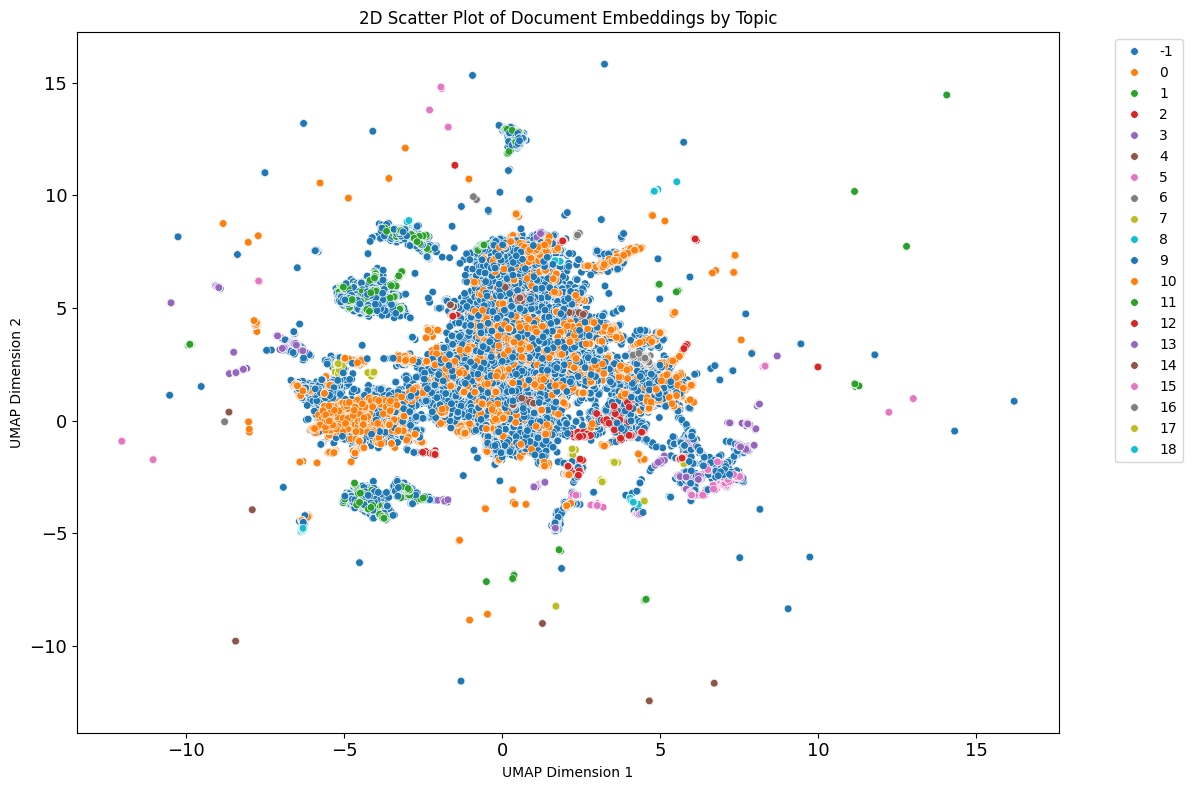

In [ ]:
embeddings = topic_model.embedding_model.embed_documents(df['processed_text'].tolist())

reduced_embeddings = topic_model.umap_model.transform(embeddings)

scatter_df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
scatter_df["topic"] = topics

plt.figure(figsize=(12, 8))
sns.scatterplot(data=scatter_df, x="x", y="y", hue="topic", palette="tab10", s=30)
plt.title("2D Scatter Plot of Document Embeddings by Topic")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()


In [ ]:
topic_0 = df[df['topic'] == 0]
topic_0.to_csv("/content/drive/My Drive/missouri_topic_0.csv", index=False)

In [ ]:
topic_0['word_count'].describe()

,word_count
count,42411.000000
mean,264.450685
std,274.438071
min,1.000000
25%,79.000000
50%,187.000000
75%,376.000000
max,8751.000000
